In [1]:
# Import libraries
import time
from datetime import timedelta

import joblib
import pandas as pd

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


# Load the dataset
df = pd.read_csv("Loan_Data.csv")
df.columns = df.columns.str.strip()


# Select 7 features and the target
features = [
    "person_age",
    "person_income",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "credit_score",
    "previous_loan_defaults_on_file"
]

target = "loan_status"  # 1 = Approved, 0 = Rejected


# Prepare the data
data = df[features + [target]].dropna().copy()

# Validate income before division
if (data["person_income"] <= 0).any():
    raise ValueError("Income must be greater than zero")

# Calculate the ratio without rounding
data["loan_percent_income"] = (
    data["loan_amnt"] / data["person_income"]
)

# Convert previous defaults to numeric values
data["previous_loan_defaults_on_file"] = (
    data["previous_loan_defaults_on_file"]
    .astype(str)
    .str.strip()
    .str.title()
    .map({"No": 0, "Yes": 1})
)

# Check that all values were converted successfully
if data["previous_loan_defaults_on_file"].isna().any():
    raise ValueError("The defaults column contains values other than Yes or No")


# Separate features and target
X = data[features]
y = data[target]


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Build the Pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(kernel="rbf", C=1.0, probability=True, random_state=42))
])


# Train the model
print("🚀Training the model, please wait...")

started_at = time.time()

pipeline.fit(X_train, y_train)

elapsed = timedelta(seconds=int(time.time() - started_at))


# Evaluate the model
y_pred = pipeline.predict(X_test)

print(f"\n📊Total rows: {len(data)}")
print(f"📊Training samples: {len(X_train)}")
print(f"📊Testing samples: {len(X_test)}")
print(f"✓Training completed in {elapsed}")

print(f"\n🎯Confusion Matrix:\n {confusion_matrix(y_test, y_pred)}")

print(f"\n🎯Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print(f"\n🎯Classification Report:\n {classification_report(y_test, y_pred, zero_division=0)}")


# Save the complete Pipeline
joblib.dump(pipeline, "loan_svc_model_v1.0.pkl")

print(f"\n💾Model saved successfully as loan_svc_model_v1.0.pkl")

🚀Training the model, please wait...

📊Total rows: 45000
📊Training samples: 36000
📊Testing samples: 9000
✓Training completed in 0:01:41

🎯Confusion Matrix:
 [[6633  367]
 [ 490 1510]]

🎯Accuracy: 0.9048

🎯Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.95      0.94      7000
           1       0.80      0.76      0.78      2000

    accuracy                           0.90      9000
   macro avg       0.87      0.85      0.86      9000
weighted avg       0.90      0.90      0.90      9000


💾Model saved successfully as loan_svc_model_v1.0.pkl


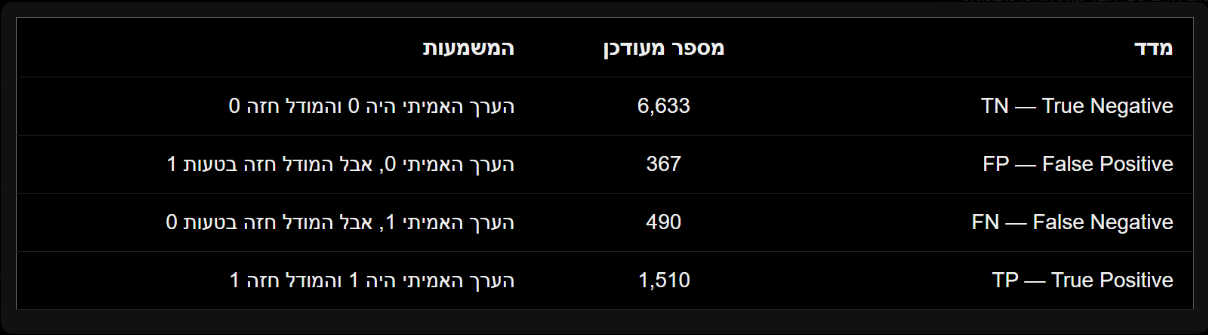